In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize

from textblob import TextBlob

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
geo = pd.read_csv('geopolitical_conflict_risk_dataset.csv')
ungdc = pd.read_csv('UNGDC_1946-2023.csv')

In [3]:
geo.head()

,country,region,month,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,sanctions_active,media_freedom_score,protest_events_last_3m,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,election_cycle,regime_type,social_media_sentiment,rolling_protest_avg_6m,instability_score,conflict_escalation_6m
0,USA,North America,2020-01,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,3,52.666619,0,45.990963,3,7,2018,22.210790,1,0,Democracy,-0.907099,2.144414,52.436131,0
1,USA,North America,2020-02,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,1,76.236598,0,79.921825,8,5,0,48.252741,0,0,Democracy,-0.457302,9.763522,98.474060,1
2,USA,North America,2020-03,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,0,130.978395,0,24.131293,4,8,2018,31.608400,1,0,Hybrid,0.122487,6.199294,80.755509,1
3,USA,North America,2020-04,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,4,158.423899,0,36.203995,4,9,2021,47.428411,0,0,Hybrid,0.389570,4.038001,58.176382,0
4,USA,North America,2020-05,0.293059,0.755706,10.483152,0.405036,111.397986,65.015718,2.672375,18.460049,5,19.204378,0,47.762006,2,9,2018,17.123555,1,0,Hybrid,-0.663418,1.264349,60.718597,0


In [4]:
ungdc.head()

,ccodealp,year,doc_id,text,session,dem_bi,country,IdealPointAll,vdem_gender,democratic_performance_name,major_power,regime_status_name,nonwest,gaiscore
0,AFG,1952,AFG_07_1952.txt,I consider it a great honour and privilege to ...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,1957,AFG_12_1957.txt,"It is my privilege to express to you, Mr. Pres...",12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,1958,AFG_13_1958.txt,138.\tBefore using this opportunity to make a ...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,1959,AFG_14_1959.txt,"69.\tI speak for a small country, Afghanistan,...",14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,1960,AFG_15_1960.txt,"At the outset, Mr. President, allow me to exte...",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("geo shape:", geo.shape)
print("ungdc shape:", ungdc.shape)
print("\ngeo columns:", geo.columns.tolist())
print("\nungdc columns:", ungdc.columns.tolist())

geo shape: (1320, 26)
ungdc shape: (10760, 14)

geo columns: ['country', 'region', 'month', 'political_stability_index', 'gdp_growth_pct', 'inflation_rate', 'unemployment_rate', 'food_price_index', 'energy_dependency_pct', 'military_expenditure_pct_gdp', 'arms_imports_index', 'border_disputes_count', 'refugee_outflow_thousands', 'sanctions_active', 'media_freedom_score', 'protest_events_last_3m', 'cyber_attack_incidents', 'last_conflict_year', 'trade_dependency_rival_pct', 'foreign_troops_present', 'election_cycle', 'regime_type', 'social_media_sentiment', 'rolling_protest_avg_6m', 'instability_score', 'conflict_escalation_6m']

ungdc columns: ['ccodealp', 'year', 'doc_id', 'text', 'session', 'dem_bi', 'country', 'IdealPointAll', 'vdem_gender', 'democratic_performance_name', 'major_power', 'regime_status_name', 'nonwest', 'gaiscore']


In [6]:
print("UNGDC year range:", ungdc['year'].min(), "–", ungdc['year'].max())
print("Geo month range: ", geo['month'].min(), "–", geo['month'].max())
print("\nUnique countries in geo: ", geo['country'].nunique())
print("Unique countries in ungdc:", ungdc['ccodealp'].nunique())

# Check overlap
geo_countries = set(geo['country'].unique())
ungdc_countries = set(ungdc['ccodealp'].unique())
print("\nCountries in both datasets:", len(geo_countries & ungdc_countries))

UNGDC year range: 1946 – 2023
Geo month range:  2020-01 – 2025-06

Unique countries in geo:  20
Unique countries in ungdc: 200

Countries in both datasets: 1


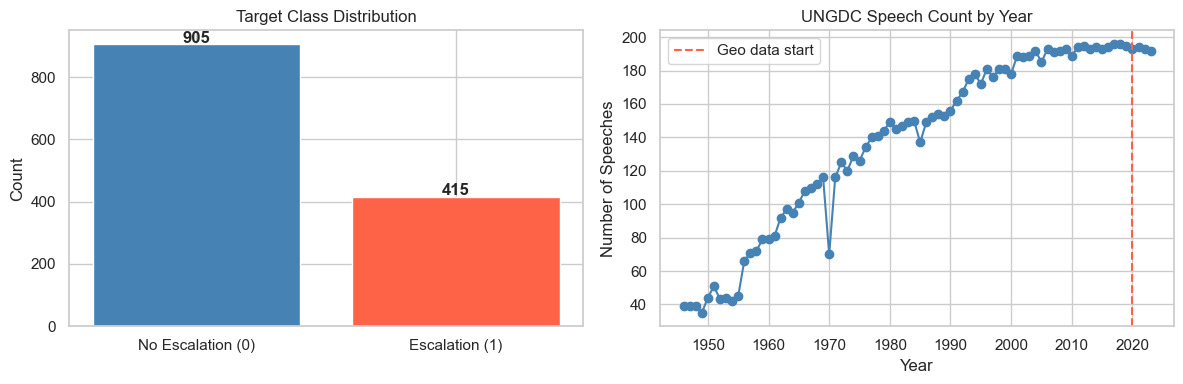

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = geo['conflict_escalation_6m'].value_counts()
axes[0].bar(['No Escalation (0)', 'Escalation (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Speech count by year (UNGDC)
speech_by_year = ungdc.groupby('year').size()
axes[1].plot(speech_by_year.index, speech_by_year.values, marker='o', linewidth=1.5, color='steelblue')
axes[1].set_title('UNGDC Speech Count by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Speeches')
axes[1].axvline(x=2020, color='tomato', linestyle='--', label='Geo data start')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
sia = SentimentIntensityAnalyzer()

def extract_vader_features(text):
    """Split speech into sentences, run VADER on each, return 5 aggregated scores."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'sent_compound_mean': np.nan,
            'sent_compound_std':  np.nan,
            'sent_pos_mean':      np.nan,
            'sent_neg_mean':      np.nan,
            'sent_neu_mean':      np.nan,
        }
    sentences = sent_tokenize(text)
    scores = [sia.polarity_scores(s) for s in sentences]
    compounds = [s['compound'] for s in scores]
    return {
        'sent_compound_mean': np.mean(compounds),
        'sent_compound_std':  np.std(compounds),
        'sent_pos_mean':      np.mean([s['pos'] for s in scores]),
        'sent_neg_mean':      np.mean([s['neg'] for s in scores]),
        'sent_neu_mean':      np.mean([s['neu'] for s in scores]),
    }

In [9]:
sample = ungdc['text'].iloc[0]
result = extract_vader_features(sample)
print("Sample VADER output:", result)
assert all(k in result for k in ['sent_compound_mean', 'sent_compound_std',
                                  'sent_pos_mean', 'sent_neg_mean', 'sent_neu_mean'])
assert -1.0 <= result['sent_compound_mean'] <= 1.0
print("Validation passed.")

Sample VADER output: {'sent_compound_mean': np.float64(0.37565185185185185), 'sent_compound_std': np.float64(0.46908430922728306), 'sent_pos_mean': np.float64(0.1784814814814815), 'sent_neg_mean': np.float64(0.059333333333333335), 'sent_neu_mean': np.float64(0.7622592592592594)}
Validation passed.


In [10]:
print(f"Extracting VADER features from {len(ungdc)} speeches...")
vader_results = ungdc['text'].apply(extract_vader_features)
vader_df = pd.DataFrame(vader_results.tolist())
ungdc_vader = pd.concat([ungdc[['ccodealp', 'year']].reset_index(drop=True),
                          vader_df.reset_index(drop=True)], axis=1)

print("ungdc_vader shape:", ungdc_vader.shape)
print(ungdc_vader.head())

Extracting VADER features from 10760 speeches...
ungdc_vader shape: (10760, 7)
  ccodealp  year  sent_compound_mean  sent_compound_std  sent_pos_mean  \
0      AFG  1952            0.375652           0.469084       0.178481   
1      AFG  1957            0.322313           0.494785       0.141222   
2      AFG  1958            0.247955           0.476461       0.129117   
3      AFG  1959            0.270622           0.463014       0.136571   
4      AFG  1960            0.315288           0.445126       0.147298   

   sent_neg_mean  sent_neu_mean  
0       0.059333       0.762259  
1       0.042400       0.816378  
2       0.057450       0.813505  
3       0.055609       0.807826  
4       0.056250       0.796481  


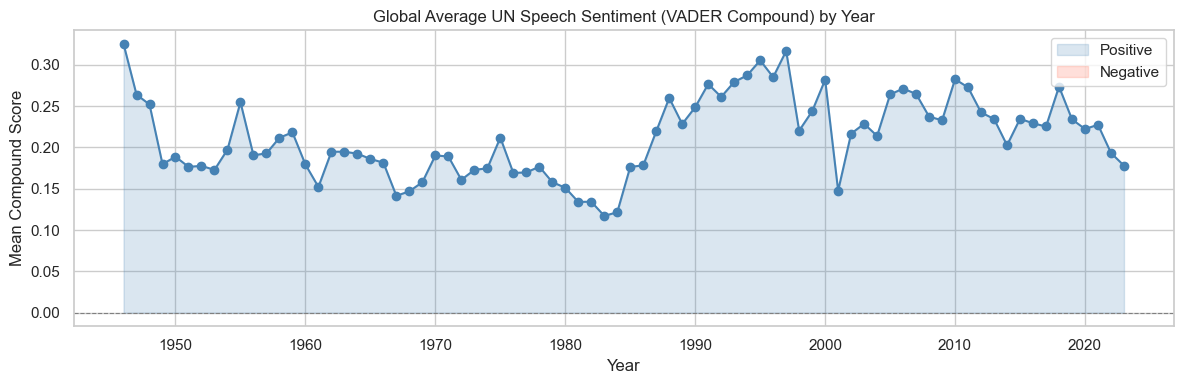

In [11]:
avg_sentiment = ungdc_vader.groupby('year')['sent_compound_mean'].mean()

plt.figure(figsize=(12, 4))
plt.plot(avg_sentiment.index, avg_sentiment.values, marker='o', linewidth=1.5, color='steelblue')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.fill_between(avg_sentiment.index, avg_sentiment.values, 0,
                 where=(avg_sentiment.values >= 0), alpha=0.2, color='steelblue', label='Positive')
plt.fill_between(avg_sentiment.index, avg_sentiment.values, 0,
                 where=(avg_sentiment.values < 0), alpha=0.2, color='tomato', label='Negative')
plt.title('Global Average UN Speech Sentiment (VADER Compound) by Year')
plt.xlabel('Year')
plt.ylabel('Mean Compound Score')
plt.legend()
plt.tight_layout()
plt.show()

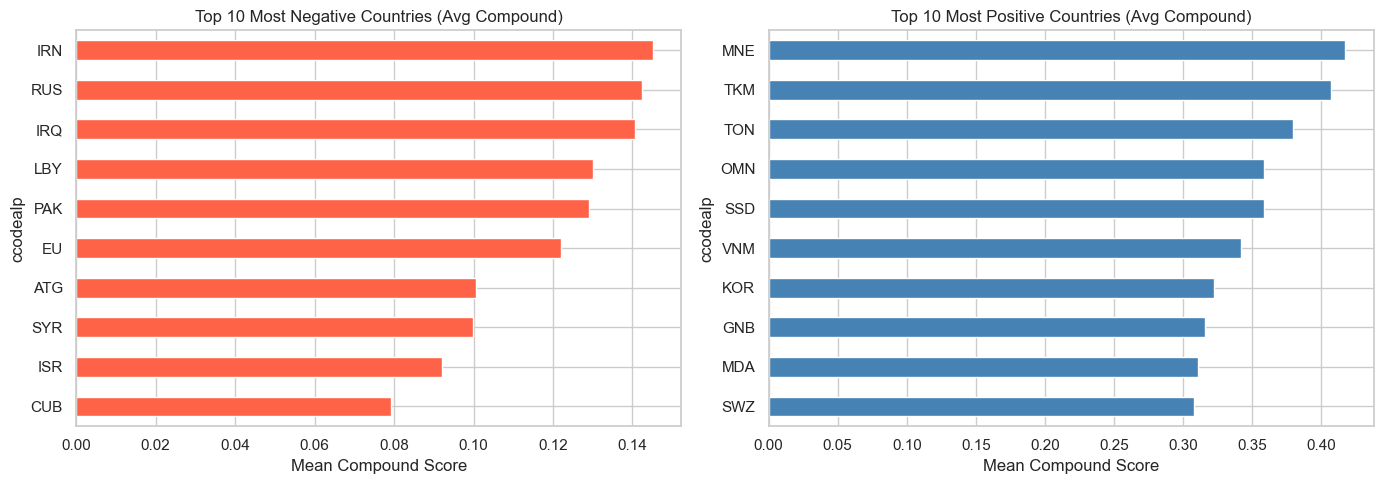

In [12]:
country_sentiment = ungdc_vader.groupby('ccodealp')['sent_compound_mean'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Most negative
country_sentiment.head(10).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Top 10 Most Negative Countries (Avg Compound)')
axes[0].set_xlabel('Mean Compound Score')

# Most positive
country_sentiment.tail(10).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Most Positive Countries (Avg Compound)')
axes[1].set_xlabel('Mean Compound Score')

plt.tight_layout()
plt.show()

In [13]:
def extract_textblob_features(text):
    """Split speech into sentences, run TextBlob on each, return polarity and subjectivity."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'tb_polarity_mean': np.nan, 'tb_subjectivity_mean': np.nan}
    sentences = sent_tokenize(text)
    sentiments = [TextBlob(s).sentiment for s in sentences]
    return {
        'tb_polarity_mean':     np.mean([s.polarity for s in sentiments]),
        'tb_subjectivity_mean': np.mean([s.subjectivity for s in sentiments]),
    }

# Validate on one sample
tb_sample = extract_textblob_features(ungdc['text'].iloc[0])
assert 'tb_polarity_mean' in tb_sample and 'tb_subjectivity_mean' in tb_sample
assert -1.0 <= tb_sample['tb_polarity_mean'] <= 1.0
assert 0.0 <= tb_sample['tb_subjectivity_mean'] <= 1.0
print("TextBlob sample output:", tb_sample)
print("Validation passed.")

print(f"\nExtracting TextBlob features from {len(ungdc)} speeches...")
tb_results = ungdc['text'].apply(extract_textblob_features)
tb_df = pd.DataFrame(tb_results.tolist())
ungdc_textblob = pd.concat([ungdc[['ccodealp', 'year']].reset_index(drop=True),
                             tb_df.reset_index(drop=True)], axis=1)

print("ungdc_textblob shape:", ungdc_textblob.shape)
print(ungdc_textblob.head())

TextBlob sample output: {'tb_polarity_mean': np.float64(0.14238683127572016), 'tb_subjectivity_mean': np.float64(0.3538910934744268)}
Validation passed.

Extracting TextBlob features from 10760 speeches...
ungdc_textblob shape: (10760, 4)
  ccodealp  year  tb_polarity_mean  tb_subjectivity_mean
0      AFG  1952          0.142387              0.353891
1      AFG  1957          0.124317              0.332567
2      AFG  1958          0.091072              0.330528
3      AFG  1959          0.094175              0.346055
4      AFG  1960          0.118337              0.351240


In [14]:
avg_tb    = ungdc_textblob.groupby('year')['tb_polarity_mean'].mean()
avg_vader = ungdc_vader.groupby('year')['sent_compound_mean'].mean()

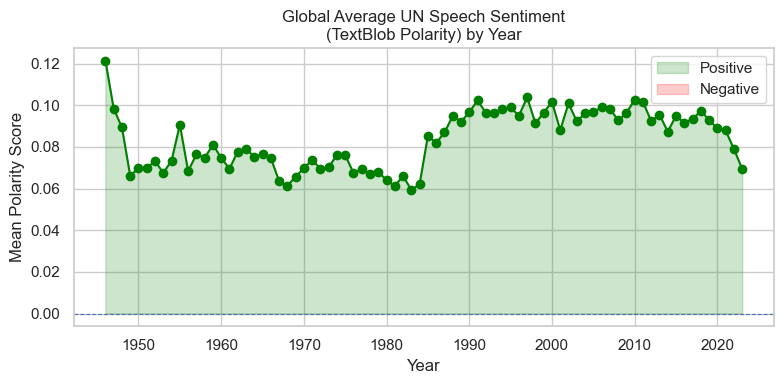

In [15]:
# --- Graph 1: TextBlob polarity over time ---
plt.figure(figsize=(8, 4))
plt.plot(avg_tb.index, avg_tb.values, marker='o', linewidth=1.5, color='green')
plt.axhline(y=0, linestyle='--', linewidth=0.8)
plt.fill_between(avg_tb.index, avg_tb.values, 0,
                 where=(avg_tb.values >= 0), alpha=0.2, label='Positive', color='green')
plt.fill_between(avg_tb.index, avg_tb.values, 0,
                 where=(avg_tb.values < 0), alpha=0.2, label='Negative', color='red')
plt.title('Global Average UN Speech Sentiment\n(TextBlob Polarity) by Year')
plt.xlabel('Year')
plt.ylabel('Mean Polarity Score')
plt.legend()
plt.tight_layout()
plt.show()

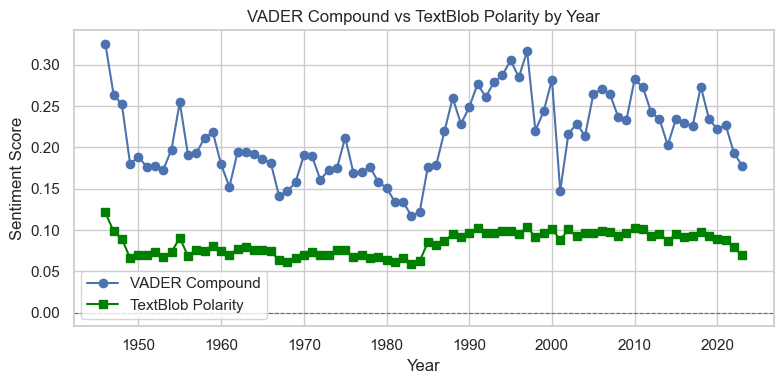

In [16]:
# --- Graph 2: VADER vs TextBlob ---
plt.figure(figsize=(8, 4))
plt.plot(avg_vader.index, avg_vader.values, marker='o', linewidth=1.5, label='VADER Compound')
plt.plot(avg_tb.index, avg_tb.values, marker='s', linewidth=1.5, label='TextBlob Polarity', color='green')
plt.axhline(y=0, linestyle='--', linewidth=0.8)
plt.title('VADER Compound vs TextBlob Polarity by Year')
plt.xlabel('Year')
plt.ylabel('Sentiment Score')
plt.legend()
plt.tight_layout()
plt.show()

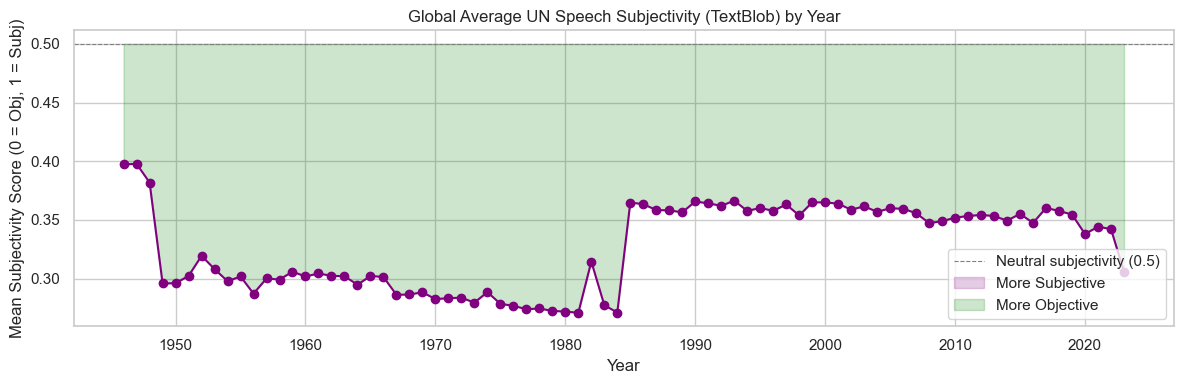

In [17]:
avg_subjectivity = ungdc_textblob.groupby('year')['tb_subjectivity_mean'].mean()

plt.figure(figsize=(12, 4))
plt.plot(avg_subjectivity.index, avg_subjectivity.values, marker='o', linewidth=1.5, color='purple')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Neutral subjectivity (0.5)')
plt.fill_between(avg_subjectivity.index, avg_subjectivity.values, 0.5,
                 where=(avg_subjectivity.values >= 0.5), alpha=0.2, color='purple', label='More Subjective')
plt.fill_between(avg_subjectivity.index, avg_subjectivity.values, 0.5,
                 where=(avg_subjectivity.values < 0.5), alpha=0.2, color='green', label='More Objective')
plt.title('Global Average UN Speech Subjectivity (TextBlob) by Year')
plt.xlabel('Year')
plt.ylabel('Mean Subjectivity Score (0 = Obj, 1 = Subj)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
def get_applicable_months(year):
    """Return the 6 YYYY-MM strings covering Oct Y through Mar Y+1."""
    months = []
    for m in [10, 11, 12]:
        months.append(f"{int(year)}-{m:02d}")
    for m in [1, 2, 3]:
        months.append(f"{int(year)+1}-{m:02d}")
    return months

# Verify
assert get_applicable_months(2020) == [
    '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03'
]
print("Month mapping verified.")

Month mapping verified.


In [19]:
vader_cols = ['sent_compound_mean', 'sent_compound_std',
              'sent_pos_mean', 'sent_neg_mean', 'sent_neu_mean']

# Aggregate in case any country has multiple speeches in the same year
ungdc_vader_agg = ungdc_vader.groupby(['ccodealp', 'year'])[vader_cols].mean().reset_index()

rows = []
for _, row in ungdc_vader_agg.iterrows():
    for month in get_applicable_months(row['year']):
        entry = {'country': row['ccodealp'], 'month': month}
        for col in vader_cols:
            entry[col] = row[col]
        rows.append(entry)

vader_monthly = pd.DataFrame(rows)
print("vader_monthly shape:", vader_monthly.shape)
print(vader_monthly.head())

vader_monthly shape: (64560, 7)
  country    month  sent_compound_mean  sent_compound_std  sent_pos_mean  \
0     AFG  1952-10            0.375652           0.469084       0.178481   
1     AFG  1952-11            0.375652           0.469084       0.178481   
2     AFG  1952-12            0.375652           0.469084       0.178481   
3     AFG  1953-01            0.375652           0.469084       0.178481   
4     AFG  1953-02            0.375652           0.469084       0.178481   

   sent_neg_mean  sent_neu_mean  
0       0.059333       0.762259  
1       0.059333       0.762259  
2       0.059333       0.762259  
3       0.059333       0.762259  
4       0.059333       0.762259  


In [20]:
# geo uses full country names; vader_monthly uses ISO alpha-3 from UNGDC.
# Map names to ISO codes so the join produces all matching countries.
geo_name_to_iso = {
    'Brazil': 'BRA', 'China': 'CHN', 'France': 'FRA', 'Germany': 'DEU',
    'India': 'IND', 'Iran': 'IRN', 'Israel': 'ISR', 'Italy': 'ITA',
    'Japan': 'JPN', 'North Korea': 'PRK', 'Pakistan': 'PAK', 'Poland': 'POL',
    'Russia': 'RUS', 'South Korea': 'KOR', 'Spain': 'ESP',
    'Turkey': 'TUR', 'UK': 'GBR', 'USA': 'USA', 'Ukraine': 'UKR',
}
geo_iso = geo.copy()
geo_iso['country'] = geo_iso['country'].map(geo_name_to_iso)
geo_iso = geo_iso.dropna(subset=['country'])  # drops Taiwan (not a UN member, no UNGDC speech)

geo_merged = geo_iso.merge(vader_monthly, on=['country', 'month'], how='inner')

print("geo rows before join:", len(geo))
print("geo rows after inner join:", len(geo_merged))
print("Countries retained:", geo_merged['country'].nunique())
print("Null VADER values:", geo_merged[vader_cols].isnull().sum().sum())
assert len(geo_merged) > 0, "Inner join returned 0 rows — check country code alignment between datasets"

geo rows before join: 1320
geo rows after inner join: 513
Countries retained: 19
Null VADER values: 0


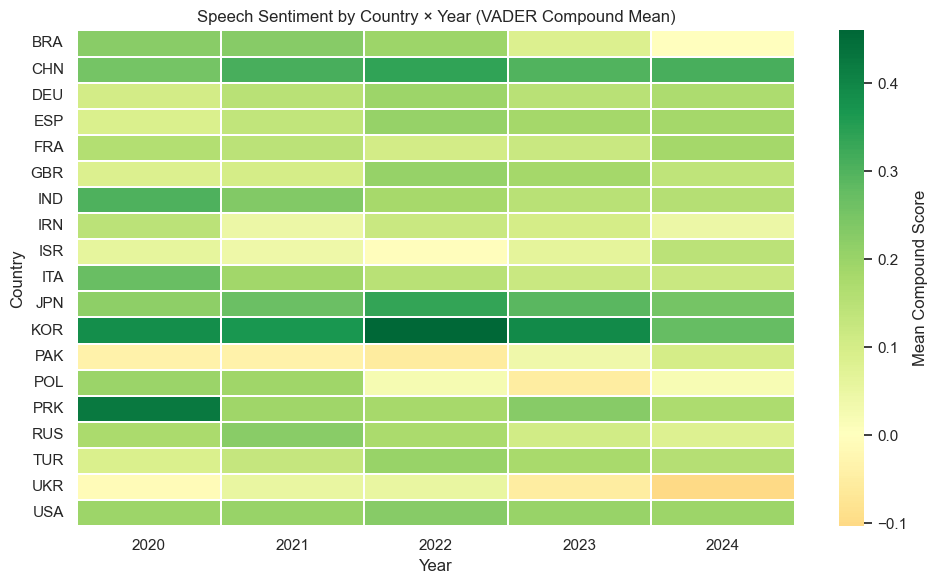

In [21]:
# Use a local copy to avoid polluting geo_merged with a year column
heatmap_df = geo_merged.copy()
heatmap_df['year'] = heatmap_df['month'].str[:4].astype(int)

heatmap_data = (heatmap_df.groupby(['country', 'year'])['sent_compound_mean']
                .mean()
                .unstack(fill_value=np.nan))

plt.figure(figsize=(10, max(6, len(heatmap_data) * 0.3)))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, annot=False,
            linewidths=0.3, cbar_kws={'label': 'Mean Compound Score'})
plt.title('Speech Sentiment by Country × Year (VADER Compound Mean)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [22]:
geo_model = pd.get_dummies(geo_merged, columns=['regime_type'], drop_first=False)

geo_cols = [
    'political_stability_index', 'gdp_growth_pct', 'inflation_rate',
    'unemployment_rate', 'food_price_index', 'energy_dependency_pct',
    'military_expenditure_pct_gdp', 'cyber_attack_incidents',
    'last_conflict_year', 'trade_dependency_rival_pct',
    'foreign_troops_present', 'election_cycle', 'social_media_sentiment',
    'rolling_protest_avg_6m', 'instability_score'
]

regime_cols = [c for c in geo_model.columns if c.startswith('regime_type_')]

feature_cols = geo_cols + vader_cols + regime_cols
target_col = 'conflict_escalation_6m'

print("Total features:", len(feature_cols))
print("Feature columns:", feature_cols)

Total features: 23
Feature columns: ['political_stability_index', 'gdp_growth_pct', 'inflation_rate', 'unemployment_rate', 'food_price_index', 'energy_dependency_pct', 'military_expenditure_pct_gdp', 'cyber_attack_incidents', 'last_conflict_year', 'trade_dependency_rival_pct', 'foreign_troops_present', 'election_cycle', 'social_media_sentiment', 'rolling_protest_avg_6m', 'instability_score', 'sent_compound_mean', 'sent_compound_std', 'sent_pos_mean', 'sent_neg_mean', 'sent_neu_mean', 'regime_type_Authoritarian', 'regime_type_Democracy', 'regime_type_Hybrid']


In [24]:
#print head of vader_monthly with USA
vader_monthly[vader_monthly['country'] == 'USA'].head()

,country,month,sent_compound_mean,sent_compound_std,sent_pos_mean,sent_neg_mean,sent_neu_mean
60606,USA,1946-10,0.337256,0.460179,0.162672,0.050784,0.786513
60607,USA,1946-11,0.337256,0.460179,0.162672,0.050784,0.786513
60608,USA,1946-12,0.337256,0.460179,0.162672,0.050784,0.786513
60609,USA,1947-01,0.337256,0.460179,0.162672,0.050784,0.786513
60610,USA,1947-02,0.337256,0.460179,0.162672,0.050784,0.786513


In [25]:
model_df = geo_model[feature_cols + [target_col]].dropna()
print(f"Rows available for modeling: {len(model_df)}")

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train class balance: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).to_dict()}")

Rows available for modeling: 513
Train size: 410, Test size: 103
Train class balance: {0: 0.6609756097560976, 1: 0.33902439024390246}
Test  class balance: {0: 0.6601941747572816, 1: 0.33980582524271846}


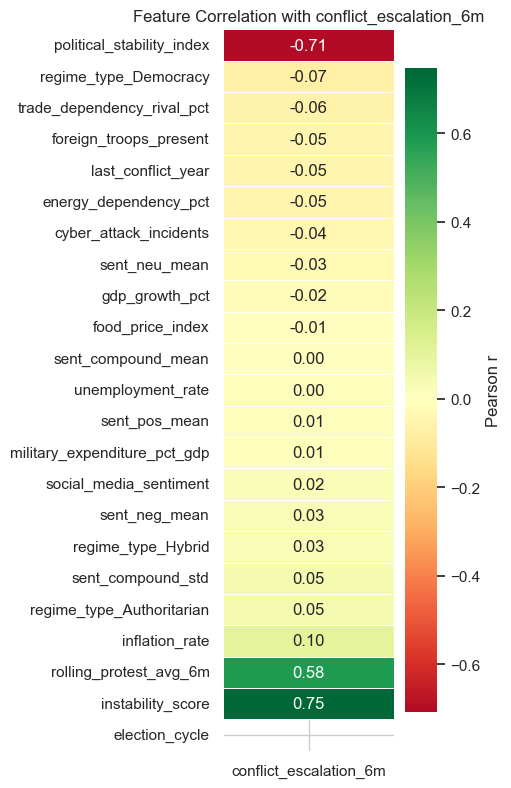

In [41]:
corr = model_df.corr(numeric_only=True)[[target_col]].drop(target_col).sort_values(target_col)

plt.figure(figsize=(5, max(6, len(corr) * 0.35)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title(f'Feature Correlation with {target_col}')
plt.tight_layout()
plt.show()

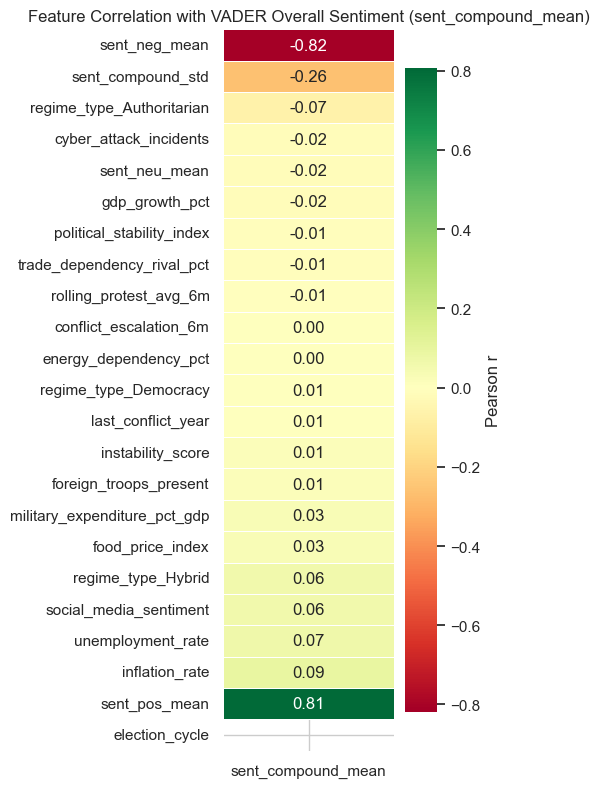

In [40]:
# Correlation with overall VADER sentiment (sent_compound_mean)
corr_vader = model_df.corr(numeric_only=True)[['sent_compound_mean']].drop('sent_compound_mean').sort_values('sent_compound_mean')

plt.figure(figsize=(5, max(6, len(corr_vader) * 0.35)))
sns.heatmap(corr_vader, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation with VADER Overall Sentiment (sent_compound_mean)')
plt.tight_layout()
plt.show()

In [46]:
# Logistic Regression based on sentiment features only
sentiment_model_df = model_df[vader_cols + [target_col]].dropna()

X_sentiment = sentiment_model_df[vader_cols]
y_sentiment = sentiment_model_df[target_col]

X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

# Scale and train
scaler_sent = StandardScaler()
X_train_sent_scaled = scaler_sent.fit_transform(X_train_sent)
X_test_sent_scaled = scaler_sent.transform(X_test_sent)

lr_sentiment = LogisticRegression(max_iter=1000, random_state=42)
lr_sentiment.fit(X_train_sent_scaled, y_train_sent)

y_pred_sent = lr_sentiment.predict(X_test_sent_scaled)
y_prob_sent = lr_sentiment.predict_proba(X_test_sent_scaled)[:, 1]

sentiment_metrics = {
    'Accuracy':  accuracy_score(y_test_sent, y_pred_sent),
    'Precision': precision_score(y_test_sent, y_pred_sent),
    'Recall':    recall_score(y_test_sent, y_pred_sent),
    'F1':        f1_score(y_test_sent, y_pred_sent),
    'ROC-AUC':   roc_auc_score(y_test_sent, y_prob_sent),
}

print("--- Logistic Regression (Sentiment Only) ---")
for k, v in sentiment_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

--- Logistic Regression (Sentiment Only) ---
  Accuracy  : 0.6602
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  ROC-AUC   : 0.4139


/opt/homebrew/Caskroom/miniconda/base/envs/data_sci/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


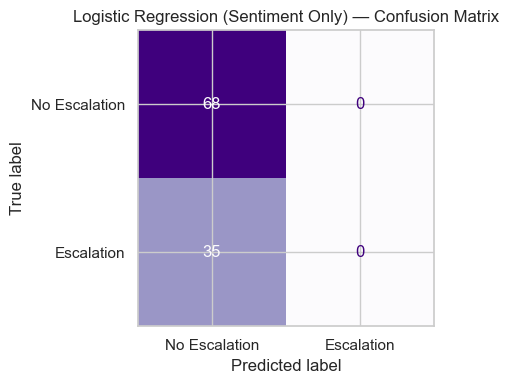

In [47]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test_sent, y_pred_sent, ax=ax,
                                         display_labels=['No Escalation', 'Escalation'],
                                         colorbar=False, cmap='Purples')
ax.set_title('Logistic Regression (Sentiment Only) — Confusion Matrix')
plt.tight_layout()
plt.show()

In [48]:
# Comparison of all models
comparison_all = pd.DataFrame({
    'Sentiment Only (LR)': sentiment_metrics,
    'Full Features (LR)': lr_metrics,
    'Full Features (RF)': rf_metrics,
})
print("\n=== Model Comparison ===")
print(comparison_all.to_string())
print("\nConclusion: Sentiment alone is a poor predictor of conflict escalation.")
print("The full feature set (geopolitical + sentiment) is essential for prediction accuracy.")


=== Model Comparison ===
           Sentiment Only (LR)  Full Features (LR)  Full Features (RF)
Accuracy              0.660194            0.873786            0.922330
Precision             0.000000            0.843750            0.864865
Recall                0.000000            0.771429            0.914286
F1                    0.000000            0.805970            0.888889
ROC-AUC               0.413866            0.948739            0.942437

Conclusion: Sentiment alone is a poor predictor of conflict escalation.
The full feature set (geopolitical + sentiment) is essential for prediction accuracy.


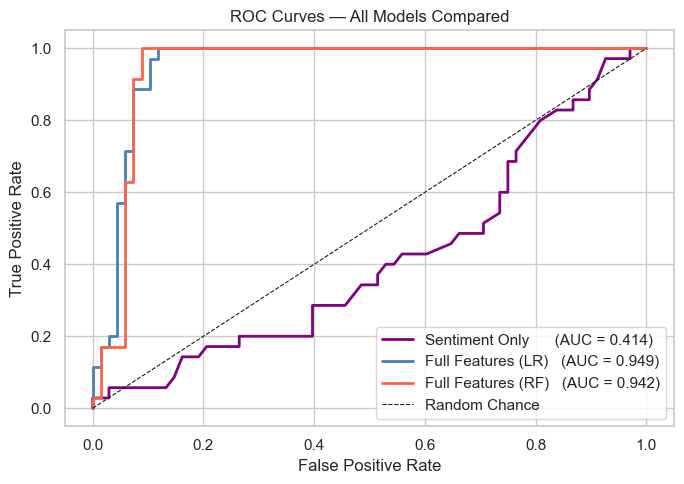

In [45]:
fpr_sent, tpr_sent, _ = roc_curve(y_test_sent, y_prob_sent)

plt.figure(figsize=(7, 5))
plt.plot(fpr_sent, tpr_sent, label=f"Sentiment Only      (AUC = {sentiment_metrics['ROC-AUC']:.3f})",
         color='purple', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f"Full Features (LR)   (AUC = {lr_metrics['ROC-AUC']:.3f})",
         color='steelblue', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Full Features (RF)   (AUC = {rf_metrics['ROC-AUC']:.3f})",
         color='tomato', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models Compared')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [28]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall':    recall_score(y_test, y_pred_lr),
    'F1':        f1_score(y_test, y_pred_lr),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_lr),
}

print("--- Logistic Regression ---")
for k, v in lr_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

--- Logistic Regression ---
  Accuracy  : 0.8738
  Precision : 0.8438
  Recall    : 0.7714
  F1        : 0.8060
  ROC-AUC   : 0.9487


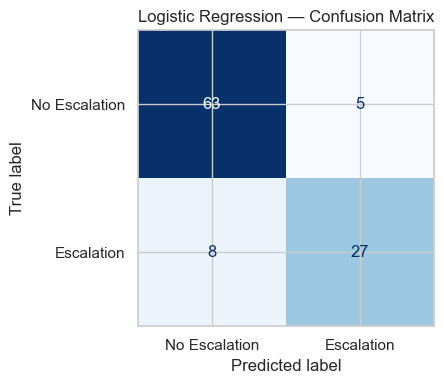

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax,
                                         display_labels=['No Escalation', 'Escalation'],
                                         colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [31]:
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall':    recall_score(y_test, y_pred_rf),
    'F1':        f1_score(y_test, y_pred_rf),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_rf),
}

print("--- Random Forest ---")
for k, v in rf_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

--- Random Forest ---
  Accuracy  : 0.9223
  Precision : 0.8649
  Recall    : 0.9143
  F1        : 0.8889
  ROC-AUC   : 0.9424


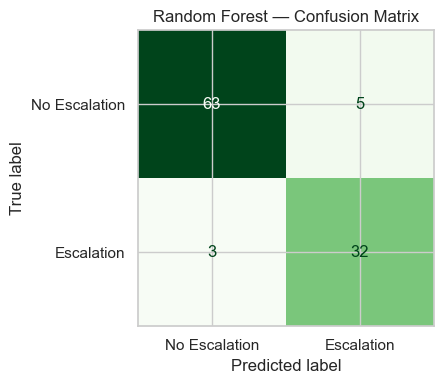

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax,
                                         display_labels=['No Escalation', 'Escalation'],
                                         colorbar=False, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

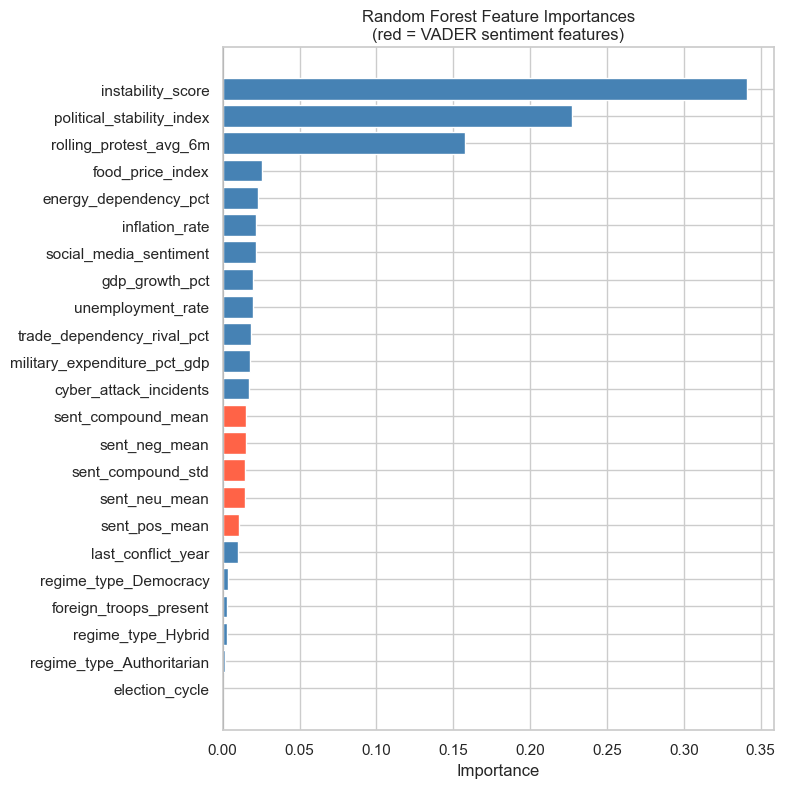

In [33]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Color VADER features differently
colors = ['tomato' if f in vader_cols else 'steelblue' for f in importances.index]

plt.figure(figsize=(8, max(6, len(importances) * 0.35)))
bars = plt.barh(importances.index, importances.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('Random Forest Feature Importances\n(red = VADER sentiment features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [34]:
comparison = pd.DataFrame({'Logistic Regression': lr_metrics,
                            'Random Forest':       rf_metrics})
print(comparison.to_string())
comparison

           Logistic Regression  Random Forest
Accuracy              0.873786       0.922330
Precision             0.843750       0.864865
Recall                0.771429       0.914286
F1                    0.805970       0.888889
ROC-AUC               0.948739       0.942437


,Logistic Regression,Random Forest
Accuracy,0.873786,0.922330
Precision,0.843750,0.864865
Recall,0.771429,0.914286
F1,0.805970,0.888889
ROC-AUC,0.948739,0.942437


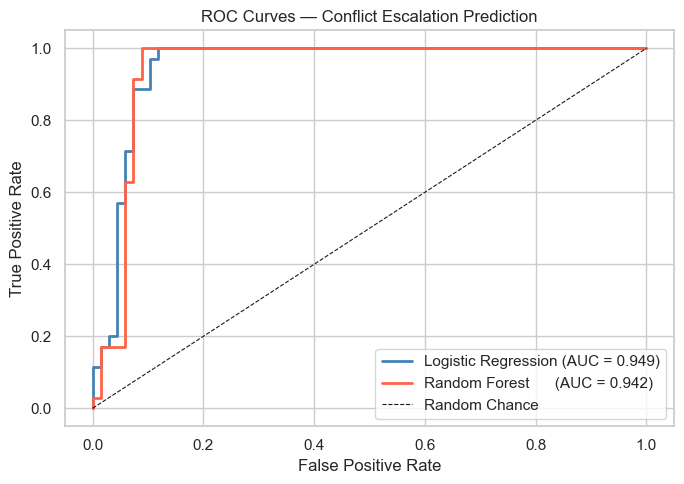

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})",
         color='steelblue', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest      (AUC = {rf_metrics['ROC-AUC']:.3f})",
         color='tomato', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Conflict Escalation Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()